In [3]:
import pandas as pd
import numpy as np

file_name = "AL-Dataset/2020_al_data_kaggle_upload_new_old_syllabi.csv"

print("=" * 60)
print("1. LOADING AND CLEANING DATASET")
print("=" * 60)

# Load data treating '-' and spaces as NaN
df = pd.read_csv(file_name, na_values=["-", "", " ", "Absent"])

# Convert Zscore to numeric
if "Zscore" in df.columns:
    df["Zscore"] = pd.to_numeric(df["Zscore"], errors="coerce")

# Extract numeric values from rank strings (e.g. '4336 (NEW)' -> 4336)
for rank_col in ["district_rank", "island_rank"]:
    if rank_col in df.columns:
        df[f"{rank_col}_num"] = (
            df[rank_col]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )

print(f"Total Records (Rows): {df.shape[0]:,}")
print(f"Total Columns:        {df.shape[1]}")
print(f"Duplicate Rows:       {df.duplicated().sum():,}")

print("\n" + "=" * 60)
print("2. COLUMN HEALTH & MISSING VALUES")
print("=" * 60)
overview = pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Count": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2),
    "Unique Values": df.nunique()
})
print(overview.to_string())

print("\n" + "=" * 60)
print("3. NUMERIC SUMMARY STATISTICS")
print("=" * 60)
numeric_summary = df.describe().T
print(numeric_summary.to_string())

print("\n" + "=" * 60)
print("4. CATEGORICAL DISTRIBUTIONS (TOP 5 VALUES PER COLUMN)")
print("=" * 60)
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

for col in categorical_cols:
    print(f"\n--- Distribution: {col} ---")
    val_counts = df[col].value_counts(dropna=False).head(5)
    percentages = (df[col].value_counts(normalize=True, dropna=False) * 100).round(2).head(5)
    dist_df = pd.DataFrame({"Count": val_counts, "Percentage (%)": percentages})
    print(dist_df.to_string())

# Export summary to CSV files for easy review
overview.to_csv("profile_column_health.csv")
numeric_summary.to_csv("profile_numeric_summary.csv")
print("\n[Done] Summary tables exported to 'profile_column_health.csv' and 'profile_numeric_summary.csv'.")

1. LOADING AND CLEANING DATASET


/tmp/ipykernel_1638/3755203406.py:11: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_name, na_values=["-", "", " ", "Absent"])


Total Records (Rows): 174,355
Total Columns:        21
Duplicate Rows:       0

2. COLUMN HEALTH & MISSING VALUES
                  Data Type  Missing Count  Missing (%)  Unique Values
index                 int64              0         0.00         174355
stream               object          71247        40.86              7
Zscore              float64          47492        27.24          31307
district_rank        object          72941        41.83           7499
island_rank          object          72941        41.83          36945
al_year               int64              0         0.00              1
sub1                 object              0         0.00             44
sub1_r               object          14731         8.45              6
sub2                 object              0         0.00             55
sub2_r               object          15768         9.04              6
sub3                 object              1         0.00             55
sub3_r               object       

Total High Performers (Z > 1.5): 11,168


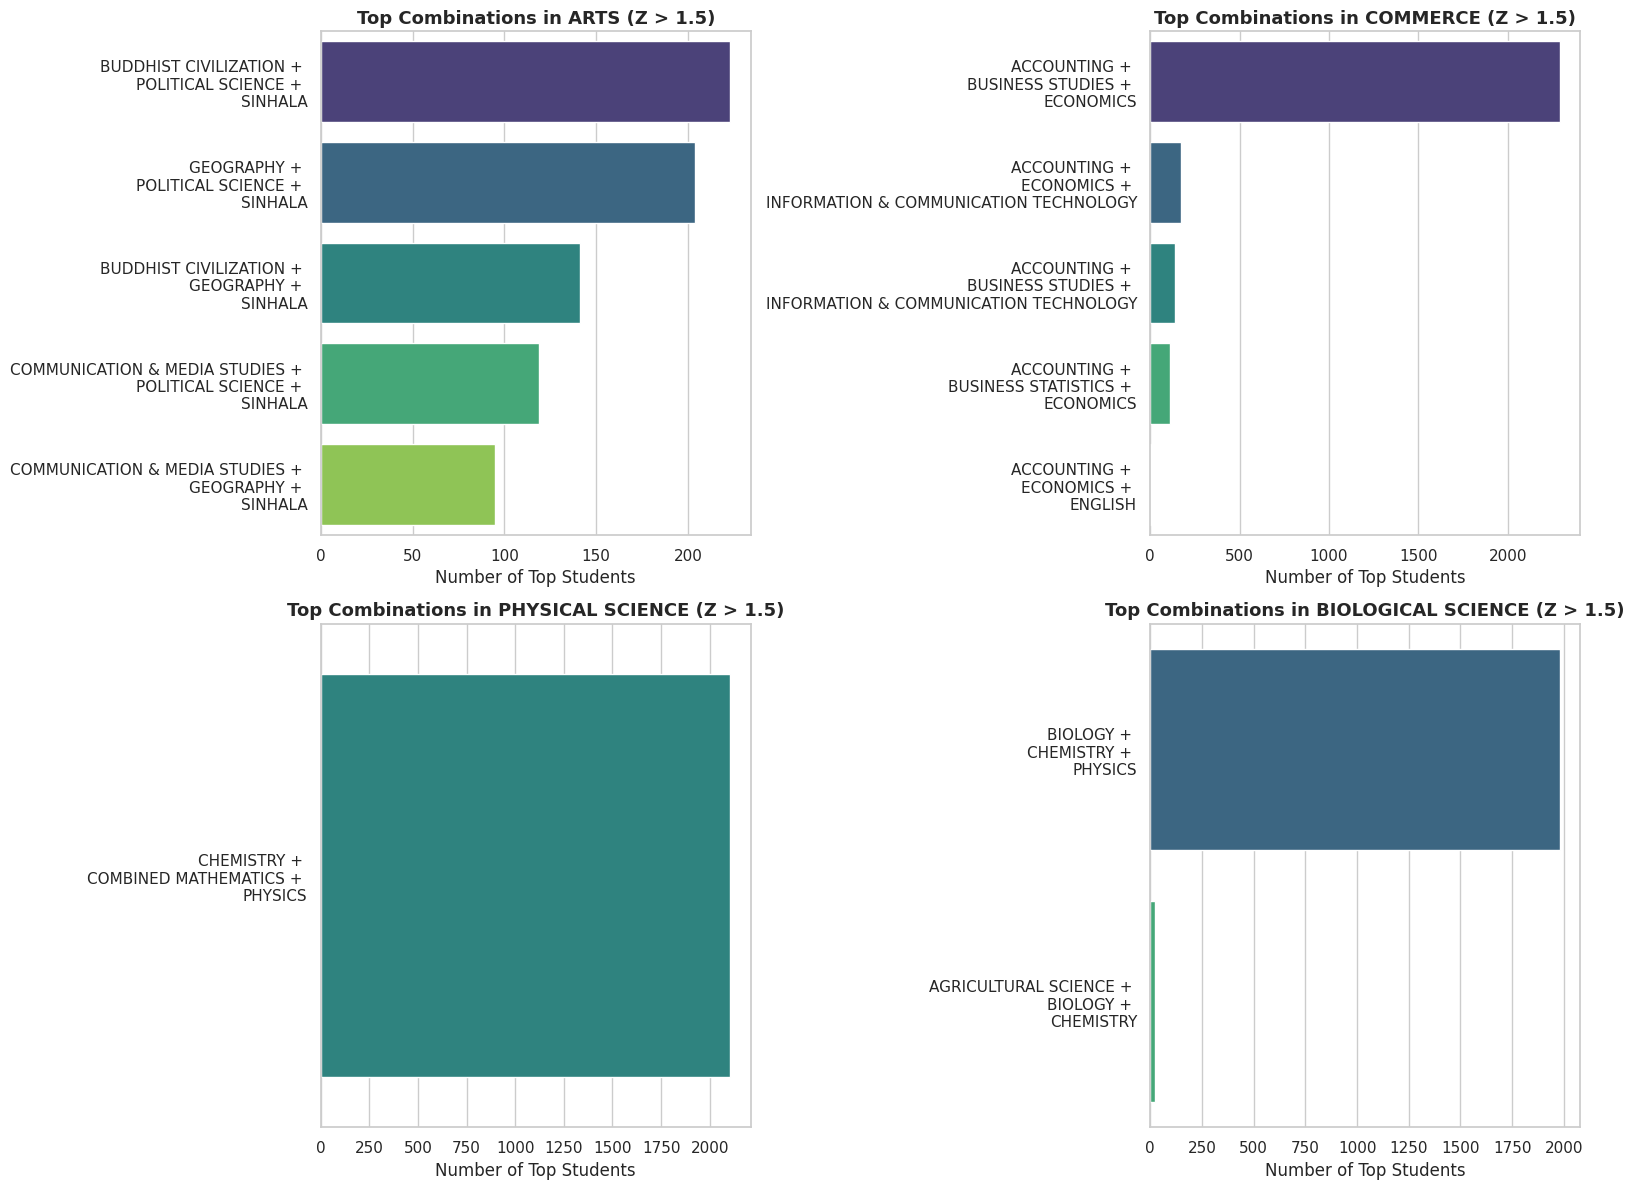

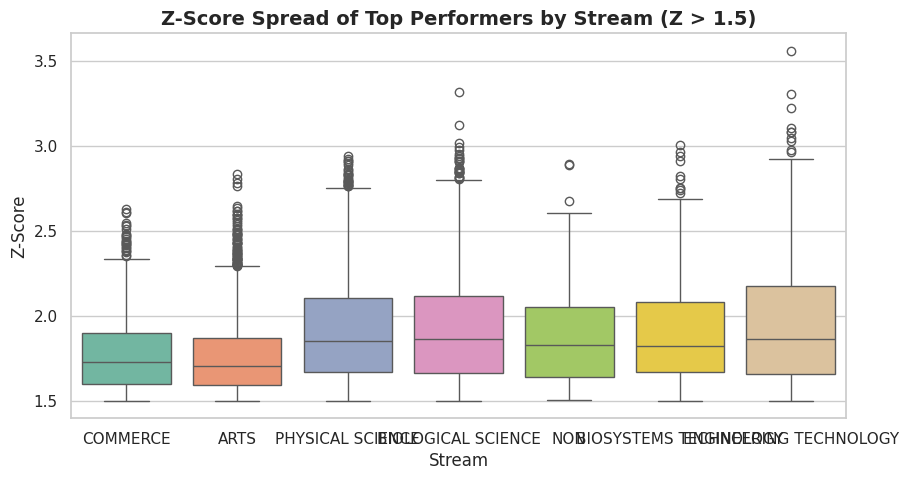

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# 1. Load and clean data
file_path = "AL-Dataset/2020_al_data_kaggle_upload_new_old_syllabi.csv"
df = pd.read_csv(file_path, na_values=["-", "", " ", "Absent"], low_memory=False)
# Convert Zscore to numeric
df["Zscore"] = pd.to_numeric(df["Zscore"], errors="coerce")

# Extract numeric island rank
if "island_rank" in df.columns:
    df["island_rank_num"] = df["island_rank"].astype(str).str.extract(r"(\d+)").astype(float)

# 2. Filter for Elite / Top Performers (Z > 1.5)
elite_df = df[df["Zscore"] > 1.5].copy()

# 3. Create a standardized Subject Combination column
# Clean and sort subject names per row to avoid order mismatches
def get_combination(row):
    subjects = [str(row[col]).strip() for col in ["sub1", "sub2", "sub3"] if pd.notnull(row[col])]
    if len(subjects) == 3:
        return " + \n".join(sorted(subjects))
    return np.nan

elite_df["subject_combination"] = elite_df.apply(get_combination, axis=1)
elite_df = elite_df.dropna(subset=["subject_combination", "stream"])

print(f"Total High Performers (Z > 1.5): {len(elite_df):,}")

# 4. Visual Representation: Top Subject Combinations by Stream
streams = elite_df["stream"].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, stream in enumerate(streams):
    stream_data = elite_df[elite_df["stream"] == stream]
    top_combos = stream_data["subject_combination"].value_counts().head(5)

    sns.barplot(
        x=top_combos.values,
        y=top_combos.index,
        ax=axes[i],
        palette="viridis",
        hue=top_combos.index,
        legend=False
    )

    axes[i].set_title(f"Top Combinations in {stream} (Z > 1.5)", fontsize=13, fontweight="bold")
    axes[i].set_xlabel("Number of Top Students")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# 5. Visual Representation: Z-Score Distribution of Top Performers
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=elite_df,
    x="stream",
    y="Zscore",
    palette="Set2",
    hue="stream",
    legend=False
)
plt.title("Z-Score Spread of Top Performers by Stream (Z > 1.5)", fontsize=14, fontweight="bold")
plt.xlabel("Stream")
plt.ylabel("Z-Score")
plt.show()

Total Students with 3 A's: 5,129

--- 3 A's Breakdown by Stream ---
stream
COMMERCE                  2341
ARTS                      1500
PHYSICAL SCIENCE           787
BIOLOGICAL SCIENCE         409
ENGINEERING TECHNOLOGY      50
BIOSYSTEMS TECHNOLOGY       28
NON                         14


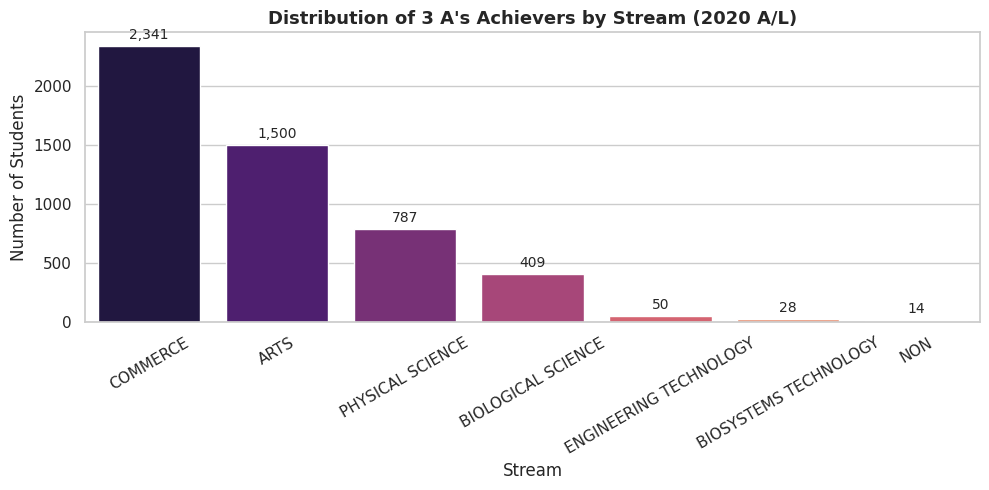


[Done] Filtered records saved to 'students_with_3A.csv'.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10})

# 1. Load data
file_path = "AL-Dataset/2020_al_data_kaggle_upload_new_old_syllabi.csv"
df = pd.read_csv(file_path, na_values=["-", "", " ", "Absent"], low_memory=False)

# 2. Standardize results to uppercase and strip whitespace
for col in ["sub1_r", "sub2_r", "sub3_r"]:
    df[col] = df[col].astype(str).str.strip().str.upper()

# 3. Filter for students who achieved 3 'A' passes across all 3 main subjects
three_a_mask = (df["sub1_r"] == "A") & (df["sub2_r"] == "A") & (df["sub3_r"] == "A")
three_a_df = df[three_a_mask].copy()

# 4. Count and breakdown by stream
stream_counts = three_a_df["stream"].value_counts(dropna=False)

print("=" * 50)
print(f"Total Students with 3 A's: {len(three_a_df):,}")
print("=" * 50)
print("\n--- 3 A's Breakdown by Stream ---")
print(stream_counts.to_string())

# 5. Visual Representation: 3 A's Count by Stream
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    x=stream_counts.index,
    y=stream_counts.values,
    palette="magma",
    hue=stream_counts.index,
    legend=False
)

# Add exact count labels on top of each bar
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height()):,}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 3),
        textcoords="offset points"
    )

plt.title("Distribution of 3 A's Achievers by Stream (2020 A/L)", fontsize=13, fontweight="bold")
plt.xlabel("Stream")
plt.ylabel("Number of Students")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 6. Export filtered results
three_a_df.to_csv("students_with_3A.csv", index=False)
print("\n[Done] Filtered records saved to 'students_with_3A.csv'.")

In [7]:
import pandas as pd
import numpy as np

# 1. Load the already extracted 3 A's CSV file directly
file_path = "students_with_3A.csv"
df_3a = pd.read_csv(file_path, na_values=["-", "", " "], low_memory=False)

print(f"Loaded records: {len(df_3a):,}")

# 2. Standardize text columns (strip whitespace & fix title casing)
text_cols = ["stream", "sub1", "sub2", "sub3", "gender", "syllabus", "birth_month"]
for col in text_cols:
    if col in df_3a.columns:
        df_3a[col] = (
            df_3a[col]
            .astype(str)
            .str.strip()
            .str.title()
            .replace({"Nan": np.nan, "None": np.nan})
        )

# 3. Clean numeric ranks (extract digits from '4336 (NEW)' -> 4336.0)
for rank_col in ["district_rank", "island_rank"]:
    if rank_col in df_3a.columns:
        df_3a[f"{rank_col}_clean"] = (
            df_3a[rank_col]
            .astype(str)
            .str.extract(r"(\d+)")
            .astype(float)
        )

# 4. Clean Zscore to numeric float
if "Zscore" in df_3a.columns:
    df_3a["Zscore"] = pd.to_numeric(df_3a["Zscore"], errors="coerce")

# 5. Clean remaining results (e.g., General English)
if "ge_r" in df_3a.columns:
    df_3a["ge_r"] = (
        df_3a["ge_r"]
        .astype(str)
        .str.strip()
        .str.upper()
        .replace({"NAN": np.nan, "-": np.nan})
    )

# 6. Parse standard birth date (YYYY-MM-DD)
if {"birth_year", "birth_month", "birth_day"}.issubset(df_3a.columns):
    df_3a["birth_date"] = pd.to_datetime(
        df_3a["birth_year"].astype(str) + "-" +
        df_3a["birth_month"].astype(str) + "-" +
        df_3a["birth_day"].astype(str),
        format="mixed",
        errors="coerce"
    )

# 7. Drop duplicate rows
df_3a = df_3a.drop_duplicates()

# 8. Overwrite and save cleaned data
output_file = "cleaned_students_with_3A.csv"
df_3a.to_csv(output_file, index=False)

print(f"Cleaning complete! Saved {len(df_3a):,} rows to '{output_file}'.")

Loaded records: 5,129
Cleaning complete! Saved 5,129 rows to 'cleaned_students_with_3A.csv'.
